In [1]:
# Import required libraries
import pandas as pd

In [2]:
# Load dataset
df = pd.read_csv("ev_battery_health_data.csv")

In [3]:
# 1. View first 5 rows
print("HEAD:")
df.head()

HEAD:


,total_distance_km,average_trip_speed_kmph,ambient_temperature_C,trip_duration_min,charging_cycles,fast_charging_ratio_%,average_battery_temperature_C,battery_health_%
0,15607.06,34.95,35.55,61.05,270,20.82,37.86,75.37
1,38077.86,33.32,16.46,46.74,685,51.85,26.59,45.00
2,29547.76,27.05,22.13,87.16,533,34.93,40.50,49.18
3,24347.68,44.29,33.21,27.52,438,42.09,42.53,62.71
4,7084.73,39.06,26.87,57.03,113,1.62,33.06,87.88


In [4]:
# 2. View last 5 rows
print("TAIL:")
df.tail()

TAIL:


,total_distance_km,average_trip_speed_kmph,ambient_temperature_C,trip_duration_min,charging_cycles,fast_charging_ratio_%,average_battery_temperature_C,battery_health_%
9995,34448.58,55.08,43.33,70.32,613,30.10,46.44,45.00
9996,36002.84,21.87,36.17,71.16,633,18.92,45.43,45.00
9997,37921.61,32.15,10.68,31.57,703,31.58,25.00,45.00
9998,16502.03,37.73,24.04,44.75,287,21.02,32.57,80.56
9999,9468.48,26.89,19.01,48.99,163,25.24,25.00,85.96


In [5]:
# 3. Shape of dataset (rows, columns)
print("SHAPE:")
print(df.shape)

SHAPE:
(10000, 8)


In [6]:
# 4. Dataset info (data types, null values)
print("INFO:")
df.info()

INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   total_distance_km              10000 non-null  float64
 1   average_trip_speed_kmph        10000 non-null  float64
 2   ambient_temperature_C          10000 non-null  float64
 3   trip_duration_min              10000 non-null  float64
 4   charging_cycles                10000 non-null  int64  
 5   fast_charging_ratio_%          10000 non-null  float64
 6   average_battery_temperature_C  10000 non-null  float64
 7   battery_health_%               10000 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 625.1 KB


In [7]:
import numpy as np

In [8]:
# ==============================
# FEATURE ENGINEERING
# ==============================

# 1. Usage intensity (km per minute)
df['usage_intensity'] = df['total_distance_km'] / (df['trip_duration_min'] + 1e-5)

# 2. Thermal stress index (battery temp × fast charging impact)
df['thermal_stress'] = df['average_battery_temperature_C'] * (1 + df['fast_charging_ratio_%'] / 100)

# 3. Cycle stress factor
df['cycle_stress'] = df['charging_cycles'] * (df['fast_charging_ratio_%'] / 100)

# 4. Degradation rate proxy (distance per charging cycle)
df['distance_per_cycle'] = df['total_distance_km'] / (df['charging_cycles'] + 1)

# 5. Temperature difference impact
df['temp_diff'] = df['average_battery_temperature_C'] - df['ambient_temperature_C']

# 6. Speed efficiency (distance per unit speed)
df['speed_efficiency'] = df['total_distance_km'] / (df['average_trip_speed_kmph'] + 1e-5)

# ==============================
# DROP ORIGINAL COLUMNS
# ==============================

cols_to_drop = [
    'total_distance_km',
    'average_trip_speed_kmph',
    'ambient_temperature_C',
    'trip_duration_min',
    'charging_cycles',
    'fast_charging_ratio_%',
    'average_battery_temperature_C'
]

df = df.drop(columns=cols_to_drop)

# ==============================
# FINAL CHECK
# ==============================

print("New Shape:", df.shape)
print("\nColumns after feature engineering:\n", df.columns)
print("\nPreview:\n", df.head())

New Shape: (10000, 7)

Columns after feature engineering:
 Index(['battery_health_%', 'usage_intensity', 'thermal_stress', 'cycle_stress',
       'distance_per_cycle', 'temp_diff', 'speed_efficiency'],
      dtype='object')

Preview:
    battery_health_%  usage_intensity  thermal_stress  cycle_stress  \
0             75.37       255.643857       45.742452       56.2140   
1             45.00       814.673767       40.376915      355.1725   
2             49.18       339.005927       54.646650      186.1769   
3             62.71       884.726423       60.430877      184.3542   
4             87.88       124.228104       33.595572        1.8306   

   distance_per_cycle  temp_diff  speed_efficiency  
0           57.590627       2.31        446.553806  
1           55.507085      10.13       1142.792574  
2           55.332884      18.37       1092.338228  
3           55.461686       9.32        549.732998  
4           62.146754       6.19        181.380650  


In [9]:
# ==============================
# 1. CHECK FOR NULL VALUES
# ==============================

print("Missing Values (Column-wise):")
df.isnull().sum()

Missing Values (Column-wise):


,0
battery_health_%,0
usage_intensity,0
thermal_stress,0
cycle_stress,0
distance_per_cycle,0
temp_diff,0
speed_efficiency,0


In [10]:
# ==============================
# 2. CHECK FOR DUPLICATE ROWS
# ==============================

duplicate_count = df.duplicated().sum()
print("\nNumber of Duplicate Rows:", duplicate_count)


Number of Duplicate Rows: 0


In [11]:
# Function to detect outliers using IQR
def detect_outliers_iqr(data):
    outlier_summary = {}

    for col in data.columns:
        if data[col].dtype != 'object':
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
            outlier_summary[col] = len(outliers)

    return outlier_summary

# Apply function
outliers = detect_outliers_iqr(df)

print("Outlier Count per Column:")
print(outliers)

Outlier Count per Column:
{'battery_health_%': 0, 'usage_intensity': 761, 'thermal_stress': 17, 'cycle_stress': 306, 'distance_per_cycle': 1189, 'temp_diff': 35, 'speed_efficiency': 199}


In [12]:
# Capping outliers
def cap_outliers_iqr(data):
    df_capped = data.copy()

    for col in df_capped.columns:
        if col != 'battery_health_%':  # don't modify target
            Q1 = df_capped[col].quantile(0.25)
            Q3 = df_capped[col].quantile(0.75)
            IQR = Q3 - Q1

            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            # Apply capping
            df_capped[col] = df_capped[col].clip(lower, upper)

    return df_capped

# Apply function
df = cap_outliers_iqr(df)

print("Outliers capped successfully.")

Outliers capped successfully.


In [13]:
outliers_after = detect_outliers_iqr(df)
print("Outliers after capping:")
print(outliers_after)

Outliers after capping:
{'battery_health_%': 0, 'usage_intensity': 0, 'thermal_stress': 0, 'cycle_stress': 0, 'distance_per_cycle': 0, 'temp_diff': 0, 'speed_efficiency': 0}


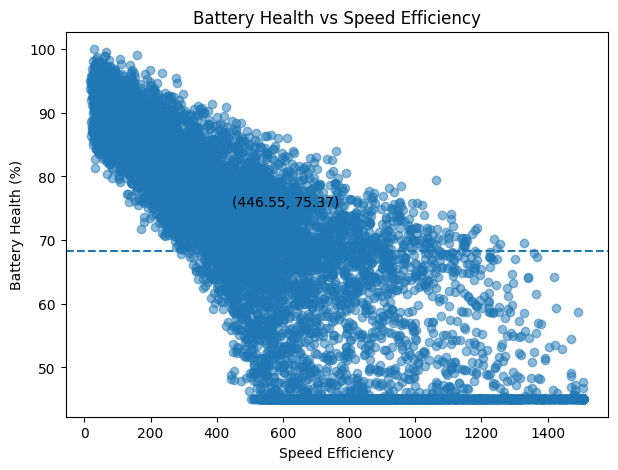

In [39]:
# Scatter Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(df["speed_efficiency"], df["battery_health_%"], alpha=0.5)

# Add mean line
mean_val = df["battery_health_%"].mean()
plt.axhline(mean_val, linestyle='--')

plt.title("Battery Health vs Speed Efficiency")
plt.xlabel("Speed Efficiency")
plt.ylabel("Battery Health (%)")

# Annotate one sample point
plt.text(
    df["speed_efficiency"].iloc[0],
    df["battery_health_%"].iloc[0],
    f"({df['speed_efficiency'].iloc[0]:.2f}, {df['battery_health_%'].iloc[0]:.2f})"
)

plt.show()

In [40]:
# Correlation with target
corr = df.corr()['battery_health_%'].sort_values(ascending=False)
print(corr)

battery_health_%      1.000000
temp_diff             0.023410
distance_per_cycle   -0.088464
thermal_stress       -0.161751
usage_intensity      -0.616689
cycle_stress         -0.669660
speed_efficiency     -0.806666
Name: battery_health_%, dtype: float64


In [15]:
# Multicollinearity Check (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns=['battery_health_%'])

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

              Feature        VIF
0     usage_intensity   3.914421
1      thermal_stress  14.449492
2        cycle_stress   4.456223
3  distance_per_cycle  23.537435
4           temp_diff   6.596614
5    speed_efficiency   5.935361


In [16]:
# Model-Based Importance
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['battery_health_%'])
y = df['battery_health_%']

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

speed_efficiency      0.727553
usage_intensity       0.102725
thermal_stress        0.057690
cycle_stress          0.051158
distance_per_cycle    0.035610
temp_diff             0.025263
dtype: float64


In [17]:
# Keep only selected features + target
df_final = df[[
    'speed_efficiency',
    'cycle_stress',
    'usage_intensity',
    'battery_health_%'
]]

print("Final Shape:", df_final.shape)
print("\nFinal Columns:\n", df_final.columns)

Final Shape: (10000, 4)

Final Columns:
 Index(['speed_efficiency', 'cycle_stress', 'usage_intensity',
       'battery_health_%'],
      dtype='object')


In [18]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df_final.drop(columns=['battery_health_%'])
y = df_final['battery_health_%']

# Step 1: Split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 2: Split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# ==============================
# CHECK SHAPES
# ==============================

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Training set shape: (7000, 3)
Validation set shape: (1500, 3)
Test set shape: (1500, 3)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [20]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

In [21]:
# Evaluation Function
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name} Performance:")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"R2: {r2:.3f}")

In [22]:
# Model 1: Random Forest + ANN
rf = RandomForestRegressor(n_estimators=100, random_state=42)
ann = MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)

rf.fit(X_train_scaled, y_train)
ann.fit(X_train_scaled, y_train)

# Hybrid prediction (average)
pred_rf = rf.predict(X_test_scaled)
pred_ann = ann.predict(X_test_scaled)

pred_avg = (pred_rf + pred_ann) / 2

# Evaluation
print("\nModel 1: RF + ANN (Averaging)")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_avg)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, pred_avg):.3f}")
print(f"R2: {r2_score(y_test, pred_avg):.3f}")


Model 1: RF + ANN (Averaging)
RMSE: 7.296
MAE: 5.589
R2: 0.803


In [23]:
# Model 2: SVR + ANN
svr = SVR(kernel='rbf', C=10)
ann2 = MLPRegressor(hidden_layer_sizes=(50,50), max_iter=500, random_state=42)

svr.fit(X_train_scaled, y_train)
ann2.fit(X_train_scaled, y_train)

pred_svr = svr.predict(X_test_scaled)
pred_ann2 = ann2.predict(X_test_scaled)

pred_avg2 = (pred_svr + pred_ann2) / 2

print("\nModel 2: SVR + ANN")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred_avg2)):.3f}")
print(f"MAE: {mean_absolute_error(y_test, pred_avg2):.3f}")
print(f"R2: {r2_score(y_test, pred_avg2):.3f}")


Model 2: SVR + ANN
RMSE: 7.312
MAE: 5.413
R2: 0.802


In [24]:
# Model 3: Stacking (RF + SVR → Linear Meta Model)
estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('svr', SVR())
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)

stack.fit(X_train_scaled, y_train)

evaluate_model("Model 3: Stacking (RF + SVR)", stack, X_test_scaled, y_test)


Model 3: Stacking (RF + SVR) Performance:
RMSE: 7.388
MAE: 5.619
R2: 0.798


In [26]:
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [27]:
# XGBoost Model
xgb = XGBRegressor(random_state=42)

xgb.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [28]:
# Prepare Data for LSTM
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [29]:
# LSTM Model
model_lstm = Sequential()
model_lstm.add(LSTM(64, activation='relu', input_shape=(1, X_train_scaled.shape[1])))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

model_lstm.fit(X_train_lstm, y_train, epochs=20, batch_size=32, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
# Hybrid Prediction
pred_xgb = xgb.predict(X_test_scaled)
pred_lstm = model_lstm.predict(X_test_lstm).flatten()

# Weighted combination
w_xgb = 0.6
w_lstm = 0.4

pred_hybrid = (w_xgb * pred_xgb) + (w_lstm * pred_lstm)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [32]:
print("\nModel 4: XGBoost + LSTM (Hybrid)")

rmse = np.sqrt(mean_squared_error(y_test, pred_hybrid))
mae = mean_absolute_error(y_test, pred_hybrid)
r2 = r2_score(y_test, pred_hybrid)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")


Model 4: XGBoost + LSTM (Hybrid)
RMSE: 7.527
MAE: 5.812
R2: 0.790


In [42]:
from sklearn.ensemble import StackingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR

# Base learners
estimators = [
    ('et', ExtraTreesRegressor(n_estimators=100, random_state=42)),
    ('dt', DecisionTreeRegressor(random_state=42)),
    ('lgbm', LGBMRegressor(random_state=42)),
    ('svr', SVR(C=10, kernel='rbf'))
]

# Meta learner
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0)
)

# Train
stack_model.fit(X_train_scaled, y_train)

# Evaluate
evaluate_model(
    "Model 5: Stacking (ET + DT + LGBM + SVR → Ridge)",
    stack_model,
    X_test_scaled,
    y_test
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000409 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 3
[LightGBM] [Info] Start training from score 68.484254
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000319 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 5600, number of used features: 3
[LightGBM] [Info] Start training from score 68.523361
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000332 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 5600, number of used features: 3
[LightGBM] [Info] Start training f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000304 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 5600, number of used features: 3
[LightGBM] [Info] Start training from score 68.491493
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000319 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 5600, number of used features: 3
[LightGBM] [Info] Start training from score 68.349823


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 5600, number of used features: 3
[LightGBM] [Info] Start training from score 68.630414


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Model 5: Stacking (ET + DT + LGBM + SVR → Ridge) Performance:
RMSE: 7.295
MAE: 5.547
R2: 0.803


In [41]:
# Initialize Results + Function
results = []

def store_results(name, y_true, y_pred):
    import numpy as np
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    results.append({
        "Model": name,
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 3),
        "MAE": round(mean_absolute_error(y_true, y_pred), 3),
        "R2": round(r2_score(y_true, y_pred), 3)
    })

In [43]:
# Model 1: RF + ANN
store_results("Model 1: RF + ANN", y_test, pred_avg)

# Model 2: SVR + ANN
store_results("Model 2: SVR + ANN", y_test, pred_avg2)

# Model 3: Stacking (RF + SVR)
y_pred3 = stack.predict(X_test_scaled)
store_results("Model 3: Stacking (RF + SVR)", y_test, y_pred3)

# Model 4: XGBoost + LSTM
store_results("Model 4: XGB + LSTM", y_test, pred_hybrid)

# Model 5: Advanced Stacking (ET + DT + LGBM + SVR)
y_pred7 = stack_model.predict(X_test_scaled)
store_results("Model 5: Stacking (ET + DT + LGBM + SVR)", y_test, y_pred7)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [44]:
import pandas as pd

results_df = pd.DataFrame(results)

# Sort by RMSE (best = lowest)
results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)

print("\n📊 Model Comparison Table:")
print(results_df)


📊 Model Comparison Table:
                                      Model   RMSE    MAE     R2
0  Model 5: Stacking (ET + DT + LGBM + SVR)  7.295  5.547  0.803
1                         Model 1: RF + ANN  7.296  5.589  0.803
2                        Model 2: SVR + ANN  7.312  5.413  0.802
3              Model 3: Stacking (RF + SVR)  7.388  5.619  0.798
4                       Model 4: XGB + LSTM  7.527  5.812  0.790


In [45]:
# Ranking
results_df["RMSE_rank"] = results_df["RMSE"].rank(method='min')
results_df["MAE_rank"] = results_df["MAE"].rank(method='min')
results_df["R2_rank"] = results_df["R2"].rank(ascending=False, method='min')

# Total score
results_df["Total_score"] = (
    results_df["RMSE_rank"] +
    results_df["MAE_rank"] +
    results_df["R2_rank"]
)

# Best overall model
best_overall = results_df.sort_values(by="Total_score").iloc[0]

print("\n🏆 Best Model (Overall Performance):")
print(best_overall)


🏆 Best Model (Overall Performance):
Model          Model 5: Stacking (ET + DT + LGBM + SVR)
RMSE                                              7.295
MAE                                               5.547
R2                                                0.803
RMSE_rank                                           1.0
MAE_rank                                            2.0
R2_rank                                             1.0
Total_score                                         4.0
Name: 0, dtype: object
